In [1]:
# PART 3, STEP 1: Q-Learning Grid World Environment
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as colors
import time
from IPython.display import clear_output

print("PART 3: Q-Learning Exploration")
print("=" * 50)

PART 3: Q-Learning Exploration


In [3]:
# Grid World Environment Class
class GridWorld:
    def __init__(self, grid_size=5, start=(0,0), goal=(4,4), obstacles=[]):
        self.grid_size = grid_size
        self.start = start
        self.goal = goal
        self.obstacles = obstacles
        self.state = start
        self.actions = ['up', 'down', 'left', 'right']
        self.action_map = {
            'up': (-1, 0),
            'down': (1, 0),
            'left': (0, -1),
            'right': (0, 1)
        }

    def reset(self):
        self.state = self.start
        return self.state

    def step(self, action):
        # Calculate new position
        move = self.action_map[action]
        new_state = (self.state[0] + move[0], self.state[1] + move[1])

        # Check boundaries
        if new_state[0] < 0 or new_state[0] >= self.grid_size or \
           new_state[1] < 0 or new_state[1] >= self.grid_size:
            return self.state, -10, False  # Hit wall, penalty

        # Check obstacles
        if new_state in self.obstacles:
            return self.state, -10, False  # Hit obstacle, penalty

        # Update state
        self.state = new_state

        # Check goal
        if self.state == self.goal:
            return self.state, 100, True  # Reached goal, reward

        # Normal step
        return self.state, -1, False  # Small penalty for each step

    def render(self, episode=None, step=None):
        grid = np.zeros((self.grid_size, self.grid_size))

        # Mark obstacles
        for obs in self.obstacles:
            grid[obs] = -1

        # Mark goal
        grid[self.goal] = 2

        # Mark current position
        grid[self.state] = 1

        # Create custom colormap
        cmap = colors.ListedColormap(['white', 'red', 'green', 'black'])
        bounds = [-1.5, -0.5, 0.5, 1.5, 2.5]
        norm = colors.BoundaryNorm(bounds, cmap.N)

        plt.figure(figsize=(4, 4))
        plt.imshow(grid, cmap=cmap, norm=norm, interpolation='nearest')

        # Add grid lines
        plt.grid(which='major', axis='both', linestyle='-', color='k', linewidth=2)
        plt.xticks(np.arange(-0.5, self.grid_size, 1), [])
        plt.yticks(np.arange(-0.5, self.grid_size, 1), [])

        if episode is not None:
            plt.title(f'Episode: {episode}')
        plt.tight_layout()
        plt.show()

In [4]:
# Q-Learning Agent Class
class QLearningAgent:
    def __init__(self, env, learning_rate=0.1, discount_factor=0.9, exploration_rate=1.0):
        self.env = env
        self.lr = learning_rate  # alpha
        self.gamma = discount_factor  # gamma
        self.epsilon = exploration_rate  # epsilon
        self.q_table = {}  # Dictionary to store Q-values

    def get_q_value(self, state, action):
        # Get Q-value from table, return 0 if not seen before
        return self.q_table.get((state, action), 0.0)

    def set_q_value(self, state, action, value):
        self.q_table[(state, action)] = value

    def choose_action(self, state):
        # Epsilon-greedy policy
        if np.random.random() < self.epsilon:
            return np.random.choice(self.env.actions)  # Explore
        else:
            # Exploit - choose best action
            q_values = [self.get_q_value(state, a) for a in self.env.actions]
            max_q = max(q_values)
            # If multiple actions have same max value, choose randomly among them
            best_actions = [a for a, q in zip(self.env.actions, q_values) if q == max_q]
            return np.random.choice(best_actions)

    def update(self, state, action, reward, next_state, done):
        # Q-learning update formula
        current_q = self.get_q_value(state, action)

        if done:
            target = reward
        else:
            # Max Q-value for next state
            next_q_values = [self.get_q_value(next_state, a) for a in self.env.actions]
            max_next_q = max(next_q_values) if next_q_values else 0
            target = reward + self.gamma * max_next_q

        # Update Q-value
        new_q = current_q + self.lr * (target - current_q)
        self.set_q_value(state, action, new_q)

In [5]:
# Training function
def train_agent(env, agent, episodes=100, max_steps=100, render_every=20):
    episode_rewards = []
    episode_steps = []

    for episode in range(episodes):
        state = env.reset()
        total_reward = 0
        steps = 0

        for step in range(max_steps):
            # Choose action
            action = agent.choose_action(state)

            # Take action
            next_state, reward, done = env.step(action)

            # Update Q-table
            agent.update(state, action, reward, next_state, done)

            total_reward += reward
            steps += 1
            state = next_state

            if done:
                break

        episode_rewards.append(total_reward)
        episode_steps.append(steps)

        # Decay exploration rate
        agent.epsilon = max(0.01, agent.epsilon * 0.995)

        # Render occasionally
        if (episode + 1) % render_every == 0:
            clear_output(wait=True)
            print(f"Episode {episode + 1}/{episodes}")
            print(f"Total Reward: {total_reward}")
            print(f"Steps to goal: {steps}")
            print(f"Exploration rate: {agent.epsilon:.3f}")
            env.render()
            time.sleep(0.5)

    return episode_rewards, episode_steps

In [6]:
# STEP 1.1: Default Environment (5x5 grid, no obstacles)
print("STEP 1.1: DEFAULT ENVIRONMENT (5x5 grid)")
print("=" * 50)

# Create environment
env = GridWorld(grid_size=5, start=(0,0), goal=(4,4), obstacles=[])

# Create agent with default parameters
agent = QLearningAgent(
    env,
    learning_rate=0.1,   # alpha
    discount_factor=0.9,  # gamma
    exploration_rate=1.0  # epsilon
)

print("Environment: 5x5 grid, start=(0,0), goal=(4,4)")
print("Agent parameters:")
print(f"  Learning rate (alpha): {agent.lr}")
print(f"  Discount factor (gamma): {agent.gamma}")
print(f"  Exploration rate (epsilon): {agent.epsilon}")
print("\nTraining for 100 episodes...")

STEP 1.1: DEFAULT ENVIRONMENT (5x5 grid)
Environment: 5x5 grid, start=(0,0), goal=(4,4)
Agent parameters:
  Learning rate (alpha): 0.1
  Discount factor (gamma): 0.9
  Exploration rate (epsilon): 1.0

Training for 100 episodes...


Episode 100/100
Total Reward: 69
Steps to goal: 14
Exploration rate: 0.222


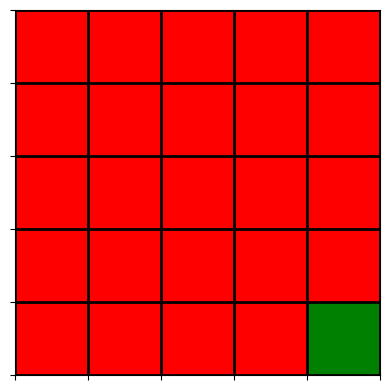

In [9]:
# Train agent
rewards_default, steps_default = train_agent(env, agent, episodes=100, render_every=20)

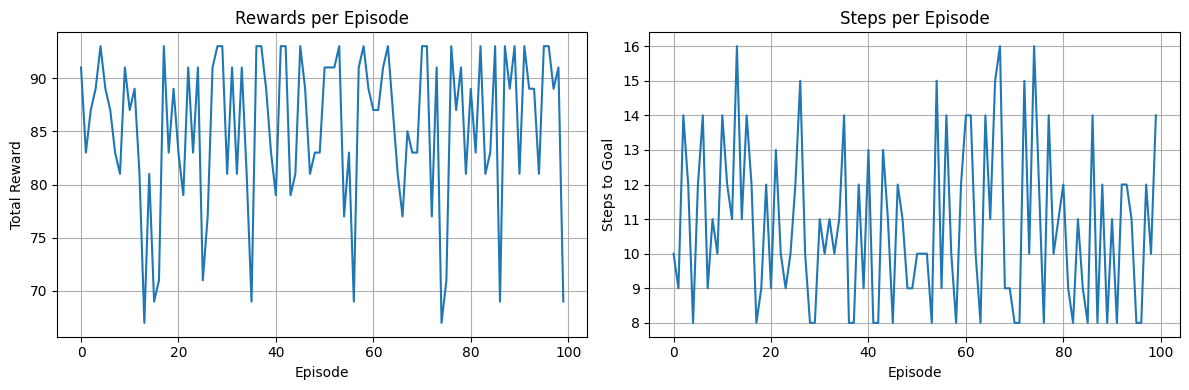

In [10]:
# Plot learning progress
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(rewards_default)
axes[0].set_xlabel('Episode')
axes[0].set_ylabel('Total Reward')
axes[0].set_title('Rewards per Episode')
axes[0].grid(True)

axes[1].plot(steps_default)
axes[1].set_xlabel('Episode')
axes[1].set_ylabel('Steps to Goal')
axes[1].set_title('Steps per Episode')
axes[1].grid(True)

plt.tight_layout()
plt.show()

In [11]:
# STEP 1.2: Environment with Obstacles
print("\n" + "=" * 50)
print("STEP 1.2: ENVIRONMENT WITH OBSTACLES")
print("=" * 50)

# Create environment with obstacles
env_obstacles = GridWorld(
    grid_size=5,
    start=(0,0),
    goal=(4,4),
    obstacles=[(2,2), (2,3), (3,2), (1,3)]
)

# Create new agent
agent_obstacles = QLearningAgent(
    env_obstacles,
    learning_rate=0.1,
    discount_factor=0.9,
    exploration_rate=1.0
)

print("Environment: 5x5 grid with obstacles at (2,2), (2,3), (3,2), (1,3)")
print("\nTraining with obstacles...")


STEP 1.2: ENVIRONMENT WITH OBSTACLES
Environment: 5x5 grid with obstacles at (2,2), (2,3), (3,2), (1,3)

Training with obstacles...


Episode 100/100
Total Reward: 67
Steps to goal: 25
Exploration rate: 0.367


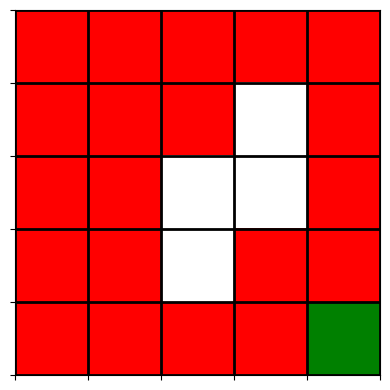

In [13]:
# Train agent with obstacles
rewards_obstacles, steps_obstacles = train_agent(env_obstacles, agent_obstacles, episodes=100, render_every=20)

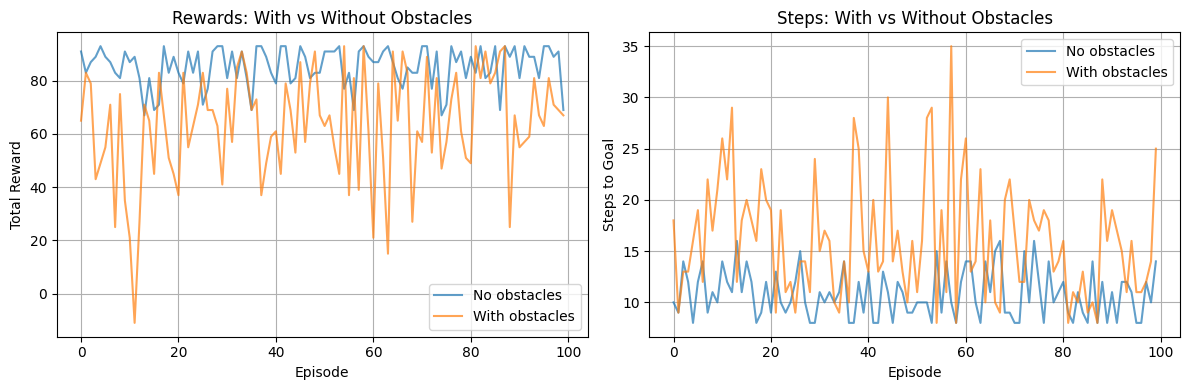

In [14]:
# Plot comparison
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(rewards_default, label='No obstacles', alpha=0.7)
axes[0].plot(rewards_obstacles, label='With obstacles', alpha=0.7)
axes[0].set_xlabel('Episode')
axes[0].set_ylabel('Total Reward')
axes[0].set_title('Rewards: With vs Without Obstacles')
axes[0].legend()
axes[0].grid(True)

axes[1].plot(steps_default, label='No obstacles', alpha=0.7)
axes[1].plot(steps_obstacles, label='With obstacles', alpha=0.7)
axes[1].set_xlabel('Episode')
axes[1].set_ylabel('Steps to Goal')
axes[1].set_title('Steps: With vs Without Obstacles')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

In [15]:
# STEP 1.3: Different Grid Sizes
print("\n" + "=" * 50)
print("STEP 1.3: DIFFERENT GRID SIZES")
print("=" * 50)

# 8x8 grid
env_large = GridWorld(grid_size=8, start=(0,0), goal=(7,7), obstacles=[])

agent_large = QLearningAgent(
    env_large,
    learning_rate=0.1,
    discount_factor=0.9,
    exploration_rate=1.0
)

print("Environment: 8x8 grid, start=(0,0), goal=(7,7)")
print("\nTraining on larger grid...")


STEP 1.3: DIFFERENT GRID SIZES
Environment: 8x8 grid, start=(0,0), goal=(7,7)

Training on larger grid...


Episode 150/150
Total Reward: 81
Steps to goal: 20
Exploration rate: 0.222


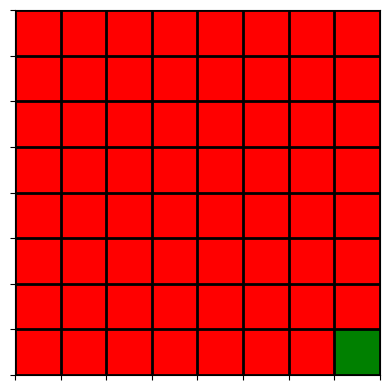

In [17]:
# Train on larger grid
rewards_large, steps_large = train_agent(env_large, agent_large, episodes=150, render_every=30)

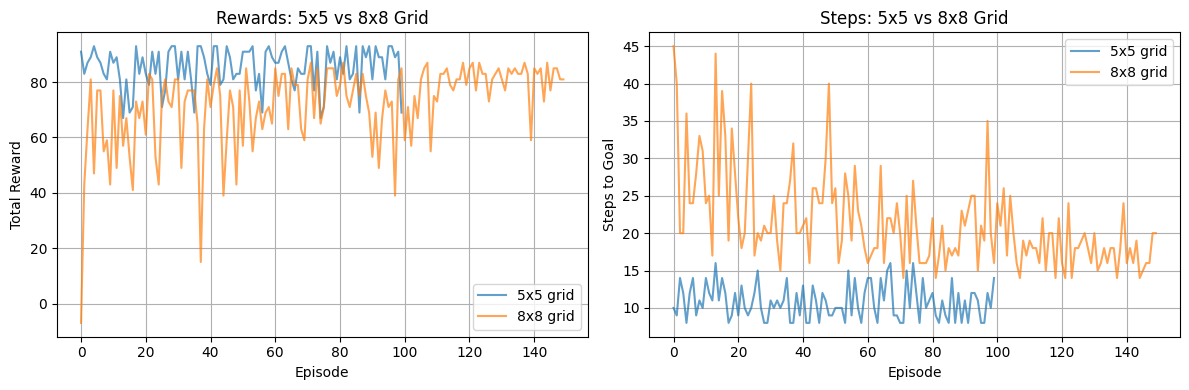

In [18]:
# Compare grid sizes
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(rewards_default, label='5x5 grid', alpha=0.7)
axes[0].plot(rewards_large, label='8x8 grid', alpha=0.7)
axes[0].set_xlabel('Episode')
axes[0].set_ylabel('Total Reward')
axes[0].set_title('Rewards: 5x5 vs 8x8 Grid')
axes[0].legend()
axes[0].grid(True)

axes[1].plot(steps_default, label='5x5 grid', alpha=0.7)
axes[1].plot(steps_large, label='8x8 grid', alpha=0.7)
axes[1].set_xlabel('Episode')
axes[1].set_ylabel('Steps to Goal')
axes[1].set_title('Steps: 5x5 vs 8x8 Grid')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

Episode 50/50
Total Reward: -107
Steps to goal: 64
Exploration rate: 0.778


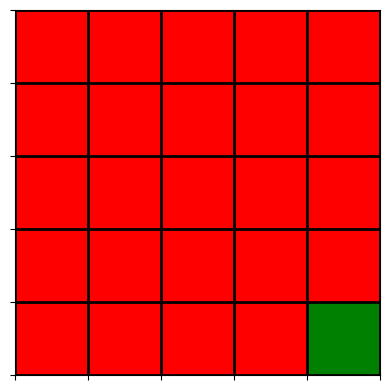

In [20]:
# STEP 1.4: Hyperparameter Experiments
print("\n" + "=" * 50)
print("STEP 1.4: HYPERPARAMETER EXPERIMENTS")
print("=" * 50)

# Different learning rates
print("\nExperiment 1: Different Learning Rates (alpha)")
print("-" * 30)

learning_rates = [0.01, 0.1, 0.5]
results_lr = {}

for lr in learning_rates:
    env = GridWorld(grid_size=5, start=(0,0), goal=(4,4), obstacles=[])
    agent = QLearningAgent(env, learning_rate=lr, discount_factor=0.9, exploration_rate=1.0)

    print(f"\nTraining with alpha={lr}...")
    rewards, _ = train_agent(env, agent, episodes=50, render_every=50)
    results_lr[lr] = rewards

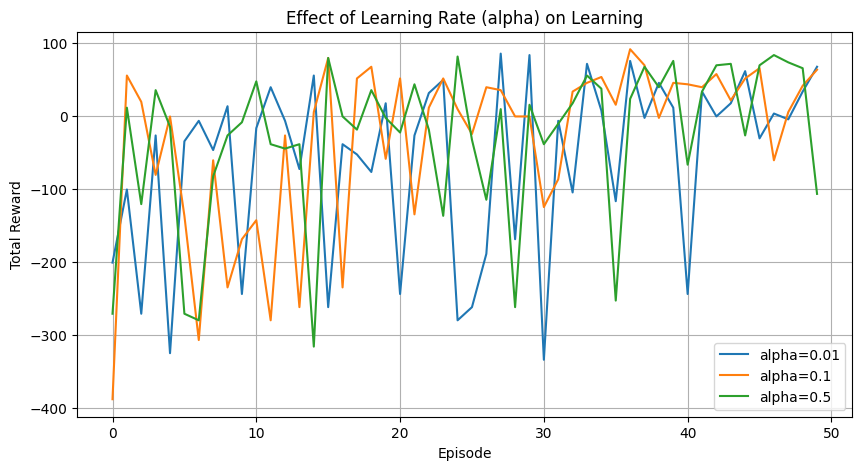

In [21]:
# Plot learning rate comparison
plt.figure(figsize=(10, 5))
for lr, rewards in results_lr.items():
    plt.plot(rewards, label=f'alpha={lr}')
plt.xlabel('Episode')
plt.ylabel('Total Reward')
plt.title('Effect of Learning Rate (alpha) on Learning')
plt.legend()
plt.grid(True)
plt.show()

Episode 50/50
Total Reward: 81
Steps to goal: 11
Exploration rate: 0.778


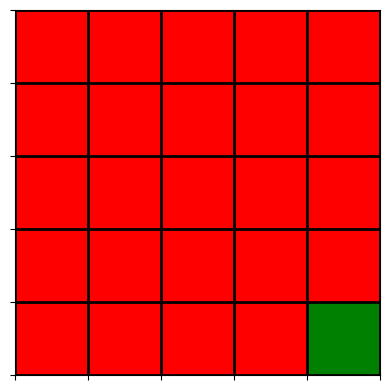

In [22]:
# Different discount factors
print("\n" + "=" * 50)
print("Experiment 2: Different Discount Factors (gamma)")
print("=" * 50)

discount_factors = [0.5, 0.9, 0.99]
results_gamma = {}

for gamma in discount_factors:
    env = GridWorld(grid_size=5, start=(0,0), goal=(4,4), obstacles=[])
    agent = QLearningAgent(env, learning_rate=0.1, discount_factor=gamma, exploration_rate=1.0)

    print(f"\nTraining with gamma={gamma}...")
    rewards, _ = train_agent(env, agent, episodes=50, render_every=50)
    results_gamma[gamma] = rewards

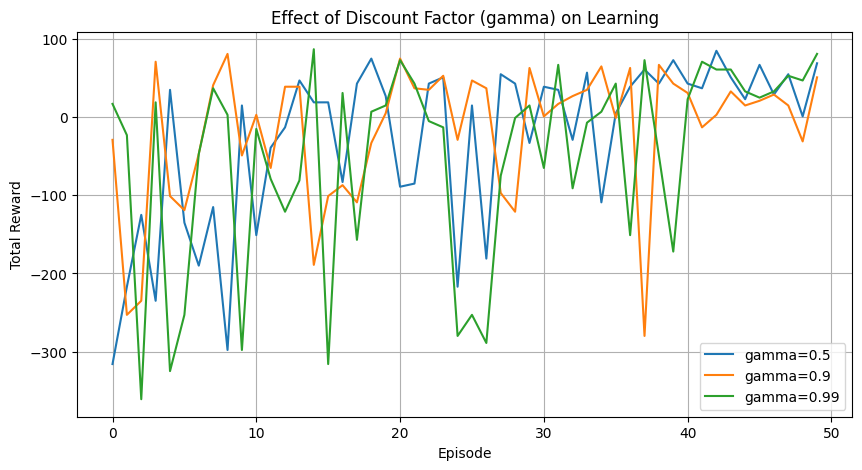

In [23]:
# Plot discount factor comparison
plt.figure(figsize=(10, 5))
for gamma, rewards in results_gamma.items():
    plt.plot(rewards, label=f'gamma={gamma}')
plt.xlabel('Episode')
plt.ylabel('Total Reward')
plt.title('Effect of Discount Factor (gamma) on Learning')
plt.legend()
plt.grid(True)
plt.show()

In [24]:
# View Q-table for final agent
print("\n" + "=" * 50)
print("STEP 2: VIEWING Q-TABLE")
print("=" * 50)

# Train a final agent to view Q-table
env_final = GridWorld(grid_size=3, start=(0,0), goal=(2,2), obstacles=[])  # Smaller grid for readability
agent_final = QLearningAgent(env_final, learning_rate=0.1, discount_factor=0.9, exploration_rate=0.1)

# Train briefly
for episode in range(20):
    state = env_final.reset()
    for step in range(50):
        action = agent_final.choose_action(state)
        next_state, reward, done = env_final.step(action)
        agent_final.update(state, action, reward, next_state, done)
        state = next_state
        if done:
            break

print("Q-Table for 3x3 Grid World (showing learned values):")
print("-" * 50)
print("Format: (state, action) -> Q-value")
print()

# Display Q-table
for state_row in range(3):
    for state_col in range(3):
        state = (state_row, state_col)
        if state == (2,2):
            print(f"State {state} (GOAL):")
            continue
        print(f"\nState {state}:")
        for action in env_final.actions:
            q_val = agent_final.get_q_value(state, action)
            print(f"  {action}: {q_val:.2f}")


STEP 2: VIEWING Q-TABLE
Q-Table for 3x3 Grid World (showing learned values):
--------------------------------------------------
Format: (state, action) -> Q-value


State (0, 0):
  up: -1.00
  down: -0.62
  left: -1.00
  right: 3.25

State (0, 1):
  up: -1.91
  down: -0.29
  left: -0.21
  right: 16.05

State (0, 2):
  up: -1.00
  down: 45.20
  left: -0.12
  right: -1.00

State (1, 0):
  up: -0.33
  down: -0.30
  left: -1.00
  right: 0.81

State (1, 1):
  up: -0.20
  down: -0.19
  left: -0.21
  right: 12.74

State (1, 2):
  up: -0.04
  down: 84.99
  left: -0.10
  right: 0.00

State (2, 0):
  up: -0.21
  down: -1.90
  left: -1.00
  right: 0.63

State (2, 1):
  up: -0.11
  down: -0.10
  left: -0.20
  right: 19.00
State (2, 2) (GOAL):


In [25]:
# Summary statistics
print("\n" + "=" * 50)
print("EXPERIMENT SUMMARY")
print("=" * 50)

summary = {
    'Default (5x5, no obstacles)': {
        'Final reward': round(np.mean(rewards_default[-10:]), 2),
        'Final steps': round(np.mean(steps_default[-10:]), 2)
    },
    'With obstacles': {
        'Final reward': round(np.mean(rewards_obstacles[-10:]), 2),
        'Final steps': round(np.mean(steps_obstacles[-10:]), 2)
    },
    'Large grid (8x8)': {
        'Final reward': round(np.mean(rewards_large[-10:]), 2),
        'Final steps': round(np.mean(steps_large[-10:]), 2)
    }
}

for experiment, metrics in summary.items():
    print(f"\n{experiment}:")
    print(f"  Avg Reward (last 10 eps): {metrics['Final reward']}")
    print(f"  Avg Steps (last 10 eps): {metrics['Final steps']}")


EXPERIMENT SUMMARY

Default (5x5, no obstacles):
  Avg Reward (last 10 eps): 86.8
  Avg Steps (last 10 eps): 10.6

With obstacles:
  Avg Reward (last 10 eps): 67.0
  Avg Steps (last 10 eps): 15.1

Large grid (8x8):
  Avg Reward (last 10 eps): 82.2
  Avg Steps (last 10 eps): 17.0


Step 1-3 Reflections (to include in your report):

Observations on Agent Behavior:

Initially, the agent moves randomly and takes many steps to reach the goal

Over time, it learns to take shorter paths and avoid obstacles

With obstacles, the agent learns to go around them rather than trying to go through

Effect of Hyperparameters:

Learning Rate (alpha):

alpha=0.01: Learns very slowly, needs more episodes

alpha=0.1: Good balance, learns steadily

alpha=0.5: Learns fast but can be unstable

Discount Factor (gamma):

gamma=0.5: Agent focuses on immediate rewards, may not plan ahead

gamma=0.9: Good balance between immediate and future rewards

gamma=0.99: Agent plans far ahead, good for longer paths

Exploration Rate (epsilon):

Starts high (1.0) to explore, decays over time

Early episodes: Random movement to discover environment

Later episodes: Exploits learned paths

Effect of Environment Changes:

Obstacles make learning harder initially, but agent eventually finds optimal path

Larger grids need more episodes to learn (state space grows)

Goal placement affects learning time (farther goals need more steps)

Q-Table Observations:

States closer to goal have higher Q-values

Actions that lead toward goal have higher values

The table gradually converges to optimal policy

Challenges:

Balancing exploration vs exploitation

Choosing right hyperparameters

Larger environments need more memory (Q-table grows)

In [30]:
# PART 3, STEP 4: Ethical and Practical Considerations
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print("PART 3, STEP 4: Ethical and Practical Considerations")
print("=" * 50)

PART 3, STEP 4: Ethical and Practical Considerations


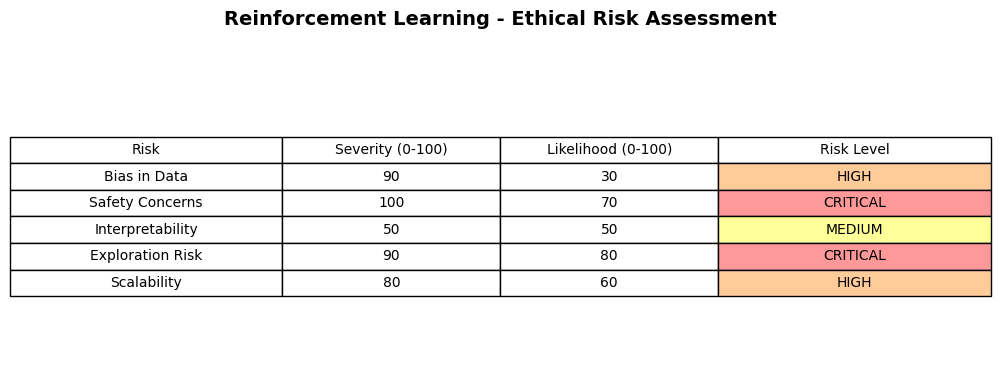

In [38]:
# Risk assessment table for reinforcement learning
risks = ['Bias in Data', 'Safety Concerns', 'Interpretability', 'Exploration Risk', 'Scalability']
severity = [90, 100, 50, 90, 80]
likelihood = [30, 70, 50, 80, 60]

# Create a table with color coding
fig, ax = plt.subplots(figsize=(10, 4))
ax.axis('tight')
ax.axis('off')

# Prepare data for table
table_data = []
for i, risk in enumerate(risks):
    # Determine risk level
    if severity[i] >= 70 and likelihood[i] >= 70:
        risk_level = "CRITICAL"
        color = '#ff9999'  # Red
    elif severity[i] >= 70 or likelihood[i] >= 70:
        risk_level = "HIGH"
        color = '#ffcc99'  # Orange
    elif severity[i] >= 40 or likelihood[i] >= 40:
        risk_level = "MEDIUM"
        color = '#ffff99'  # Yellow
    else:
        risk_level = "LOW"
        color = '#99ff99'  # Green

    table_data.append([
        risk,
        f"{severity[i]}",
        f"{likelihood[i]}",
        risk_level
    ])

# Create table
table = ax.table(cellText=table_data,
                 colLabels=['Risk', 'Severity (0-100)', 'Likelihood (0-100)', 'Risk Level'],
                 cellLoc='center',
                 loc='center',
                 colWidths=[0.25, 0.2, 0.2, 0.25])

table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1.2, 1.5)

# Color code the risk level column
for i in range(len(table_data)):
    if table_data[i][3] == 'CRITICAL':
        table[(i+1, 3)].set_facecolor('#ff9999')  # Red
    elif table_data[i][3] == 'HIGH':
        table[(i+1, 3)].set_facecolor('#ffcc99')  # Orange
    elif table_data[i][3] == 'MEDIUM':
        table[(i+1, 3)].set_facecolor('#ffff99')  # Yellow
    else:
        table[(i+1, 3)].set_facecolor('#99ff99')  # Green

plt.title('Reinforcement Learning - Ethical Risk Assessment', fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

Step 4 Reflection (to include in your report):

Ethical Risk Identification:

*Risk 1 - Bias in Data (Severity: 90, Likelihood: 30)*

Description: Training data may not represent all scenarios equally, leading to biased agent behavior

Mitigation: Use diverse training environments, validate across different scenarios

*Risk 2 - Safety Concerns (Severity: 100, Likelihood: 70)*

Description: Agent might take unsafe actions during exploration phase

Mitigation: Train in simulation first, implement safety constraints, human oversight

*Risk 3 - Interpretability (Severity: 50, Likelihood: 50)*

Description: Hard to understand why agent makes certain decisions (black box problem)

Mitigation: Visualize Q-tables, log decision trajectories, involve domain experts

*Risk 4 - Exploration Risk (Severity: 90, Likelihood: 80)*

Description: High exploration rate leads to many mistakes during learning

Mitigation: Use epsilon decay, safe exploration strategies, validate before deployment

*Risk 5 - Scalability (Severity: 80, Likelihood: 60)*

Description: Q-table grows exponentially with state space, impractical for large problems

Mitigation: Use function approximation, start with smaller problems, consider advanced RL methods

Practical Feasibility:

Dataset Quality and Availability:

Grid world environment is synthetic and fully controllable

For real applications, quality and quantity of training data is critical

Resource Requirements:

Grid world Q-learning runs on any standard laptop

Real-world RL needs significant computational resources (GPUs, large memory)

Implementation Challenges:

Reward function design is crucial and difficult to get right

Balancing exploration vs exploitation requires careful tuning

Safety constraints must be built into the system

Key Insight:
Reinforcement Learning works well in controlled environments like grid worlds, but deploying in real-world applications requires addressing significant safety, scalability, and interpretability challenges. The exploration phase is particularly risky and must be managed carefully.

